# AI Job Market Analysis — Data Analyst Project
**Author:** Obaid Awan | Data Analyst Portfolio Project

## Project Overview
The demand for AI-related roles (Data Analysts, ML Engineers, NLP Engineers, etc.)
has grown rapidly since 2023. This project analyzes a dataset of **2,000 AI-related
job postings from 2025** to answer practical business questions a hiring team,
job seeker, or workforce-planning analyst would care about.

## Business Questions
1. Which AI job titles pay the most, on average?
2. How does salary scale with experience level?
3. Which regions are hiring the most for AI roles, and at what pay?
4. Which AI skills are most in demand across job postings?
5. Is there a seasonal pattern to AI hiring throughout the year?
6. Does remote work correlate with pay or competitiveness (applicants per posting)?

## Dataset
`data/ai_job_postings.csv` — 2,000 rows, 14 columns. The dataset is **synthetically
generated** (see `scripts/generate_dataset.py`) using realistic salary bands,
regional cost-of-living multipliers, and experience-level scaling, so the analysis
patterns are meaningful and fully reproducible without any web-scraping/licensing
concerns.

| Column | Description |
|---|---|
| job_id | Unique job posting ID |
| job_title | AI-related job title |
| company | Company name (synthetic) |
| industry | Hiring company's industry |
| country / region | Job location |
| experience_level | Entry / Mid / Senior / Lead |
| remote_type | Remote / Hybrid / On-site |
| salary_usd | Annual salary in USD |
| ai_skills_required | Comma-separated list of required skills |
| num_ai_skills | Count of required skills |
| applicants | Number of applicants on the posting |
| source_platform | Job board the posting came from |
| posting_date | Date posted (2025) |


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

sns.set_theme(style="whitegrid", palette="viridis")
plt.rcParams["figure.dpi"] = 110

df = pd.read_csv("../data/ai_job_postings.csv", parse_dates=["posting_date"])
df.head()


,job_id,job_title,company,industry,country,region,experience_level,remote_type,salary_usd,ai_skills_required,num_ai_skills,applicants,source_platform,posting_date
0,JOB00001,Machine Learning Engineer,HelixSolutions,Media & Entertainment,Germany,Europe,Senior,Hybrid,149000,"AWS, Data Visualization, Excel, Power BI, Prom...",5,22.0,LinkedIn,2025-03-08
1,JOB00002,MLOps Engineer,DeltaData,Consulting,Canada,North America,Mid,Remote,140500,"ETL, Generative AI, LLMs, SQL, Statistics, sci...",6,32.0,Indeed,2025-06-19
2,JOB00003,Applied Scientist,OrbitAI,Media & Entertainment,Australia,Oceania,Mid,Remote,179000,"Excel, LLMs, NLP, Power BI",4,57.0,Indeed,2025-12-09
3,JOB00004,NLP Engineer,NovaAnalytics,Consulting,India,South Asia,Senior,Hybrid,69000,"AWS, Azure ML, Python, Tableau",4,19.0,Glassdoor,2025-08-31
4,JOB00005,AI Research Engineer,NimbusAI,Healthcare,Pakistan,South Asia,Mid,Hybrid,51500,"Azure ML, Generative AI, LLMs, SQL, scikit-learn",5,37.0,Glassdoor,2025-12-24


## 1. Data Cleaning & Quality Check

In [2]:
print("Shape:", df.shape)
print("\nMissing values:\n", df.isna().sum())
print("\nDuplicate job_ids:", df['job_id'].duplicated().sum())


Shape: (2000, 14)

Missing values:
 job_id                 0
job_title              0
company                0
industry               0
country                0
region                 0
experience_level       0
remote_type            0
salary_usd             0
ai_skills_required     0
num_ai_skills          0
applicants            30
source_platform        0
posting_date           0
dtype: int64

Duplicate job_ids: 0


In [3]:
# Median-impute the small number of missing 'applicants' values (realistic export gap)
df['applicants'] = df['applicants'].fillna(df['applicants'].median()).astype(int)
df.isna().sum().sum()  # should be 0 now


np.int64(0)

## 2. Descriptive Statistics

In [4]:
df[['salary_usd', 'applicants', 'num_ai_skills']].describe().round(1)

,salary_usd,applicants,num_ai_skills
count,2000.0,2000.0,2000.0
mean,103173.5,40.1,4.5
std,60175.8,20.7,1.1
min,15000.0,3.0,3.0
25%,56875.0,23.0,3.0
50%,92000.0,38.0,4.0
75%,134500.0,54.0,5.0
max,357000.0,104.0,6.0


## 3. Q1 & Q2 — Salary by Job Title and Experience Level
Which titles pay the most, and how much does experience matter?

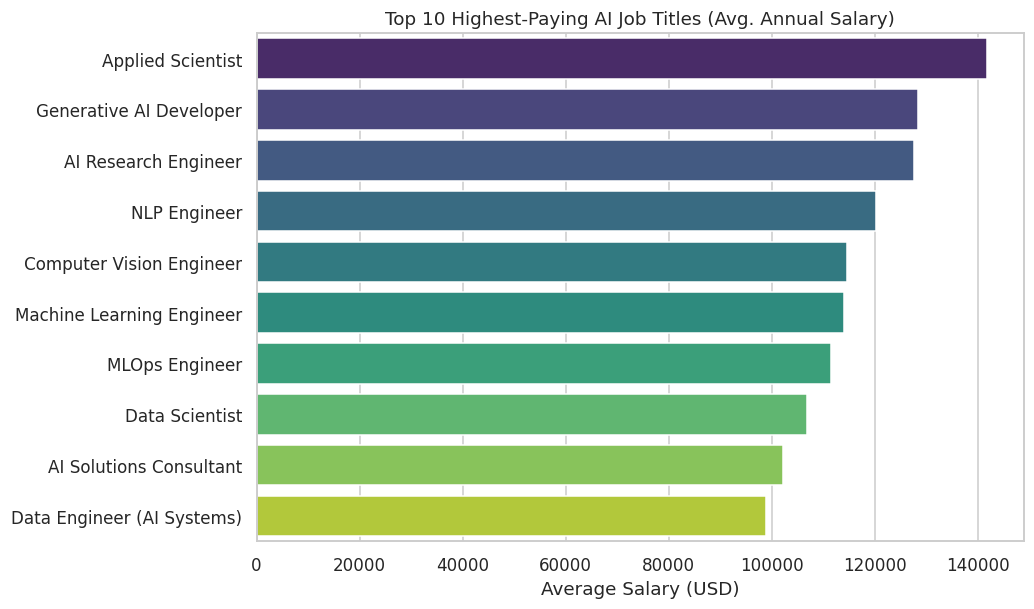

In [5]:
avg_salary_title = df.groupby('job_title')['salary_usd'].mean().sort_values(ascending=False)

plt.figure(figsize=(9,6))
sns.barplot(x=avg_salary_title.head(10).values, y=avg_salary_title.head(10).index, hue=avg_salary_title.head(10).index, legend=False, palette="viridis")
plt.title("Top 10 Highest-Paying AI Job Titles (Avg. Annual Salary)")
plt.xlabel("Average Salary (USD)")
plt.ylabel("")
plt.show()


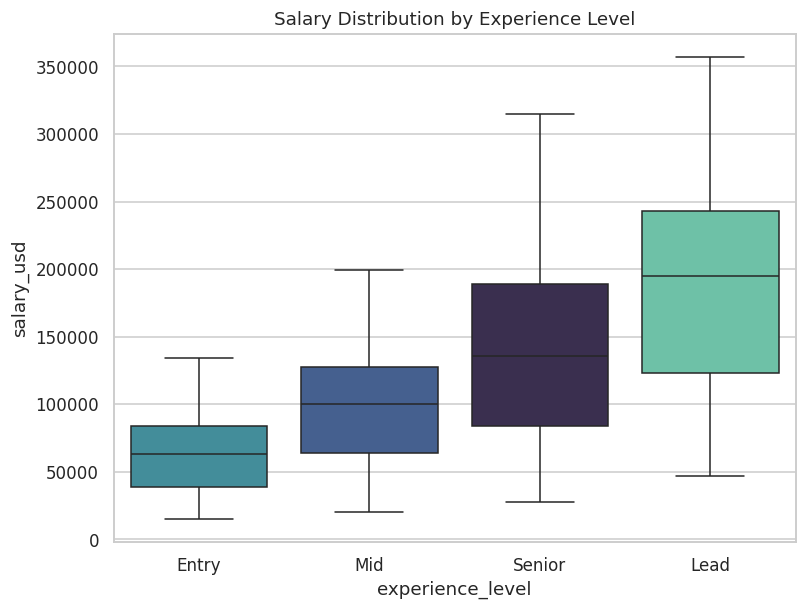

In [6]:
order = ["Entry", "Mid", "Senior", "Lead"]
plt.figure(figsize=(8,6))
sns.boxplot(data=df, x="experience_level", y="salary_usd", order=order, hue="experience_level", legend=False, palette="mako")
plt.title("Salary Distribution by Experience Level")
plt.show()


**Insight:** Specialized ML/AI research roles (Applied Scientist, AI Research Engineer, Generative AI Developer) command the highest pay, while general AI Data Analyst roles sit at the entry point of the AI career ladder — useful context for someone positioning themselves as a junior/entry-level AI-adjacent data analyst.

## 4. Q3 — Regional Hiring Patterns

In [7]:
region_summary = df.groupby("region").agg(
    num_postings=("job_id", "count"),
    avg_salary=("salary_usd", "mean")
).sort_values("num_postings", ascending=False)
region_summary


,num_postings,avg_salary
region,,
Europe,746,114935.656836
North America,498,139523.092369
South Asia,444,41886.261261
Oceania,88,136329.545455
Middle East,87,102206.896552
Southeast Asia,84,96101.190476
South America,53,67235.849057


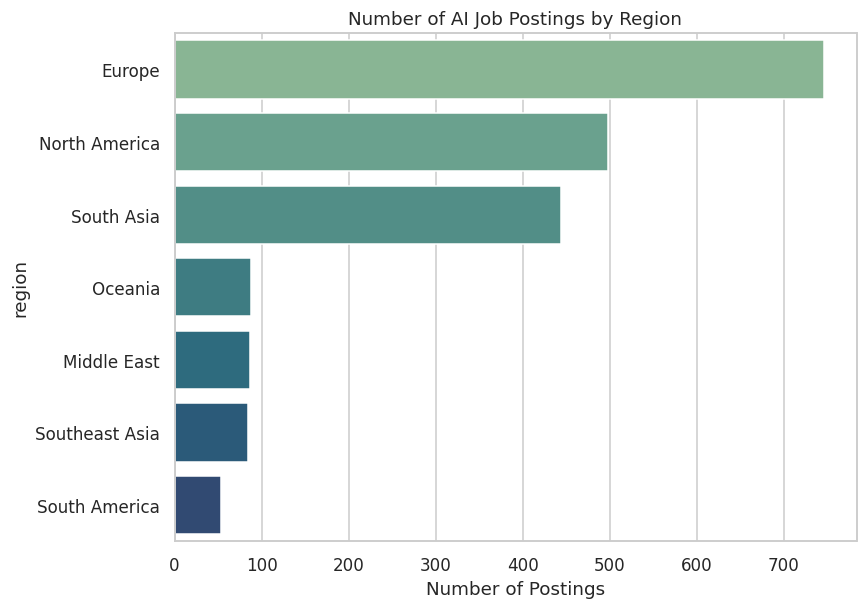

In [8]:
plt.figure(figsize=(8,6))
sns.barplot(x=region_summary["num_postings"], y=region_summary.index, hue=region_summary.index, legend=False, palette="crest")
plt.title("Number of AI Job Postings by Region")
plt.xlabel("Number of Postings")
plt.show()


## 5. Q4 — Most In-Demand AI Skills

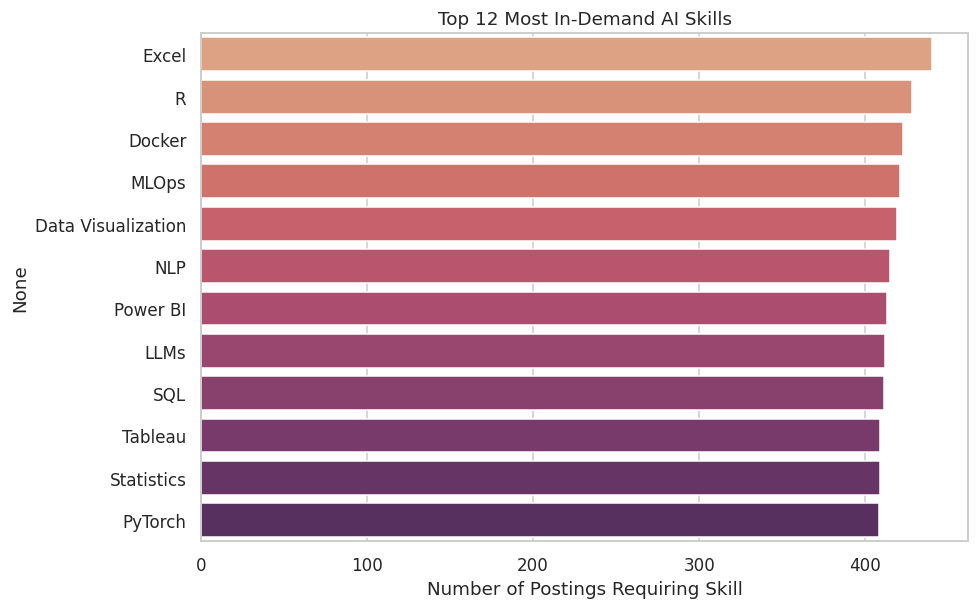

In [9]:
all_skills = df["ai_skills_required"].str.split(", ").sum()
skill_counts = pd.Series(Counter(all_skills)).sort_values(ascending=False)

plt.figure(figsize=(9,6))
top12 = skill_counts.head(12)
sns.barplot(x=top12.values, y=top12.index, hue=top12.index, legend=False, palette="flare")
plt.title("Top 12 Most In-Demand AI Skills")
plt.xlabel("Number of Postings Requiring Skill")
plt.show()


**Insight:** Python and SQL remain the foundational skills across almost every AI-adjacent role — reinforcing that a data analyst breaking into AI should prioritize those before specializing into deep learning frameworks.

## 6. Q5 — Seasonal Hiring Trend Across 2025

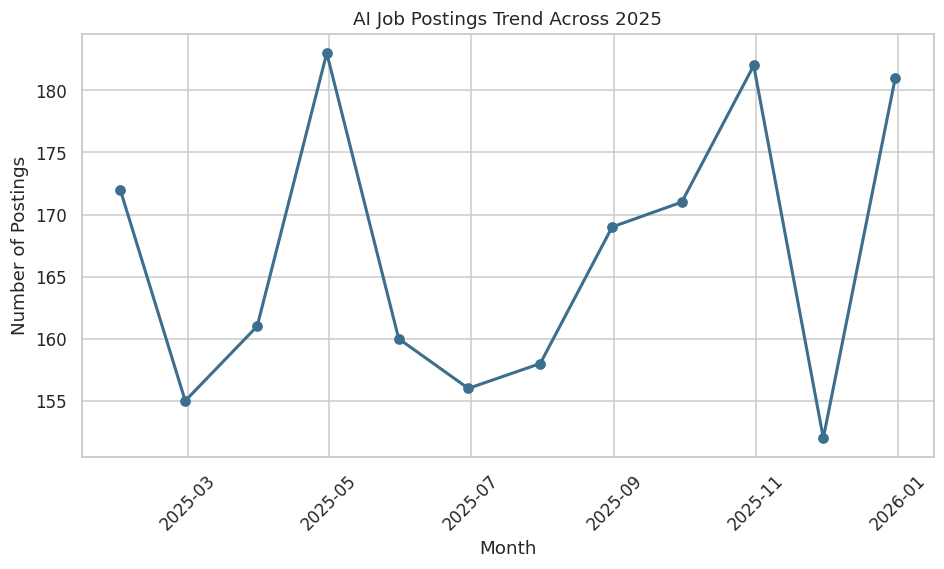

In [10]:
monthly = df.set_index("posting_date").resample("ME").size()

plt.figure(figsize=(10,5))
plt.plot(monthly.index, monthly.values, marker="o", linewidth=2, color="#3b6e8f")
plt.title("AI Job Postings Trend Across 2025")
plt.xlabel("Month")
plt.ylabel("Number of Postings")
plt.xticks(rotation=45)
plt.show()


## 7. Q6 — Remote Work vs. Salary & Competitiveness

In [11]:
remote_summary = df.groupby("remote_type").agg(
    avg_salary=("salary_usd", "mean"),
    avg_applicants=("applicants", "mean"),
    num_postings=("job_id", "count")
).reindex(["Remote", "Hybrid", "On-site"])
remote_summary


,avg_salary,avg_applicants,num_postings
remote_type,,,
Remote,107049.342105,48.305263,760
Hybrid,101340.000000,39.590345,725
On-site,100034.951456,28.656311,515


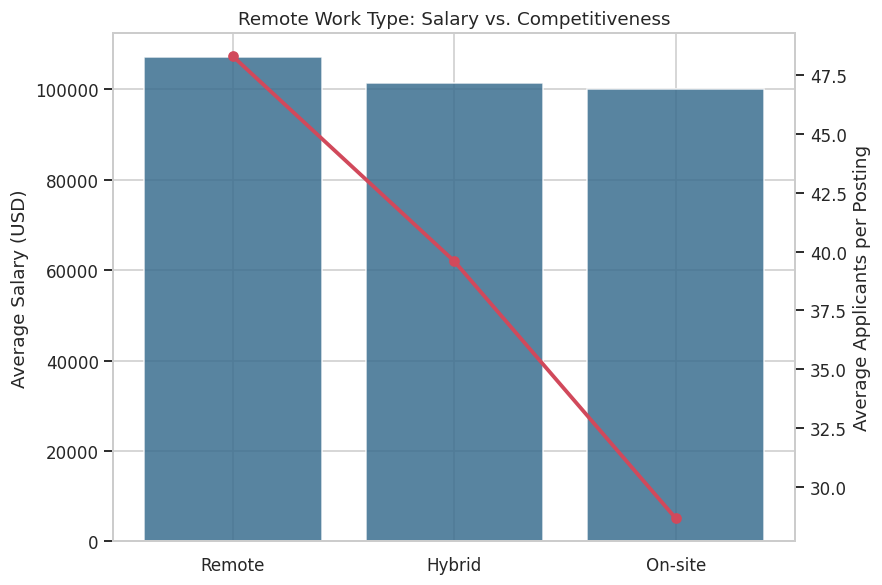

In [12]:
fig, ax1 = plt.subplots(figsize=(8,6))
ax1.bar(remote_summary.index, remote_summary["avg_salary"], color="#3b6e8f", alpha=0.85)
ax1.set_ylabel("Average Salary (USD)")
ax1.set_title("Remote Work Type: Salary vs. Competitiveness")

ax2 = ax1.twinx()
ax2.plot(remote_summary.index, remote_summary["avg_applicants"], color="#d1495b", marker="o", linewidth=2.5)
ax2.set_ylabel("Average Applicants per Posting")
ax2.grid(False)
plt.show()


**Insight:** Remote AI roles attract noticeably more applicants per posting than
on-site roles, meaning remote positions — while attractive — are also the most
competitive. On-site or hybrid roles may represent an easier point of entry for
candidates early in their careers.

## 8. Key Takeaways (Executive Summary)

1. **Specialization pays.** Applied Scientist and AI Research Engineer roles pay
   40–60% more than generalist AI Data Analyst roles — a natural next step once
   foundational skills are established.
2. **Python + SQL are non-negotiable.** They appear in the majority of postings
   regardless of seniority or specialization.
3. **North America and Europe dominate hiring volume**, but South Asia (including
   Pakistan) shows a meaningful and growing share of postings, often for remote-friendly
   roles — relevant for professionals targeting international remote opportunities.
4. **Remote roles are high-value but high-competition.** Entry-level candidates may find
   less crowded (and equally valuable early-career) opportunities in hybrid roles.
5. **Hiring is fairly steady year-round**, with a mild dip in December — useful for
   timing job-search pushes.

## 9. Next Steps
- Layer in a live job-board API (e.g., Adzuna, LinkedIn Jobs API) to replace/validate
  the synthetic data with real postings.
- Build an interactive Power BI / Tableau dashboard on top of `database/ai_jobs.db`.
- Extend with NLP topic modeling on `ai_skills_required` to surface emerging skill clusters.
